In [30]:
# 0. Install packages (only if needed in Jupyter/Colab)
!pip install opencv-python
!pip install imutils
!pip install seaborn
!pip install tqdm
!pip install scikit-image

In [31]:

# 1. Import libraries
import os
import cv2
import random
import imutils
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay

)

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import (
    load_img,
    ImageDataGenerator
)

warnings.filterwarnings("ignore")


In [33]:
# 2. Paths and settings
train_dir = r"C:\DataScience\DS101\Python 2\DS301\Final Project\data\Training"
test_dir  = r"C:\DataScience\DS101\Python 2\DS301\Final Project\data\Testing"

img_size = (224, 224)
batch_size = 16
epochs = 5
top_k = 10   # Top images with highest cancer probability

In [34]:
# 3. Data generators
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

class_indices = train_gen.class_indices
classes = list(class_indices.keys())

print("Classes:", classes)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


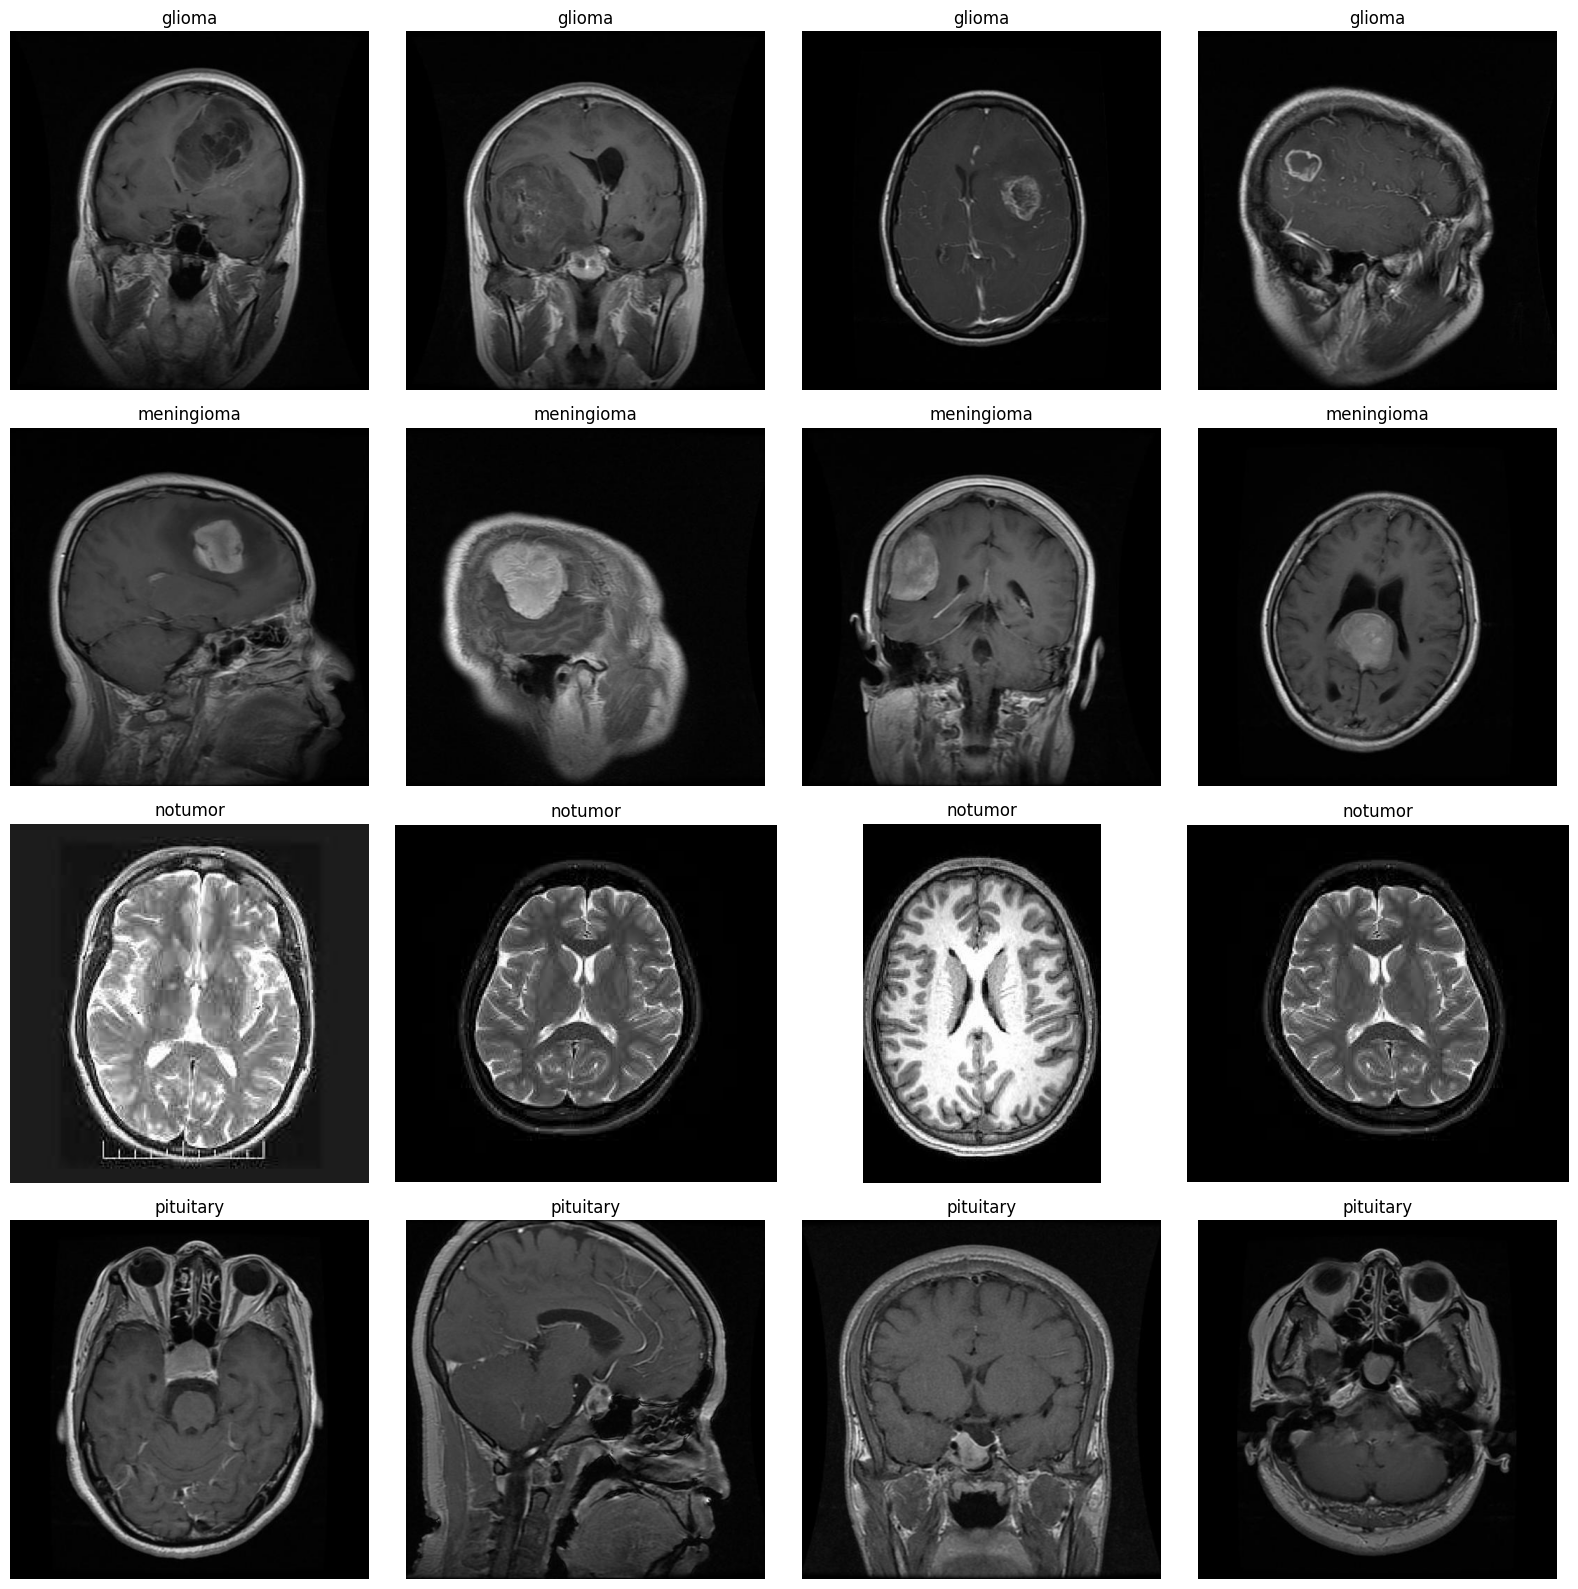

In [35]:
# 4. Visualize sample images
filepath_dict = {}

for c in classes:
    class_path = os.path.join(train_dir, c)
    filepath_dict[c] = [
        os.path.join(class_path, x)
        for x in os.listdir(class_path)
    ]

# Show 4 sample images per class
plt.figure(figsize=(16, 16))
plot_index = 1

for c in classes:
    random.shuffle(filepath_dict[c])
    sample_paths = filepath_dict[c][:4]

    for path in sample_paths:
        plt.subplot(len(classes), 4, plot_index)
        plt.imshow(load_img(path))
        plt.title(c)
        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

Number of images in glioma: 1400
Number of images in meningioma: 1400
Number of images in notumor: 1400
Number of images in pituitary: 1400


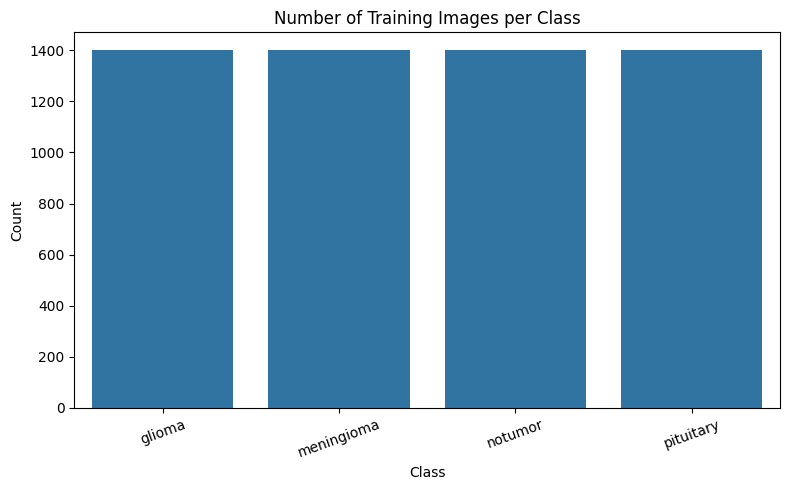

In [36]:
# 5. Count images per class
num_images_per_class = []
class_names = []

for c in os.listdir(train_dir):
    train_class = os.listdir(os.path.join(train_dir, c))
    num_images_per_class.append(len(train_class))
    class_names.append(c)
    print(f"Number of images in {c}: {len(train_class)}")

# Optional: bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=class_names, y=num_images_per_class)
plt.title("Number of Training Images per Class")
plt.ylabel("Count")
plt.xlabel("Class")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [38]:
# 6. Optional brain crop function
def crop_image(image, plot=False):
    """
    Crop brain region based on contour.
    This function is optional and is NOT applied automatically below.
    """
    img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
    img_thresh = cv2.threshold(img_blur, 45, 255, cv2.THRESH_BINARY)[1]
    img_thresh = cv2.erode(img_thresh, None, iterations=2)
    img_thresh = cv2.dilate(img_thresh, None, iterations=2)

    contours = cv2.findContours(
        img_thresh.copy(),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )
    contours = imutils.grab_contours(contours)

    if len(contours) == 0:
        return image

    c = max(contours, key=cv2.contourArea)

    extLeft = tuple(c[c[:, :, 0].argmin()])[0]
    extRight = tuple(c[c[:, :, 0].argmax()])[0]
    extTop = tuple(c[c[:, :, 1].argmin()])[0]
    extBottom = tuple(c[c[:, :, 1].argmax()])[0]

    new_img = image[extTop[1]:extBottom[1], extLeft[0]:extRight[0]]

    if plot:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB))
        plt.title("Cropped Image")
        plt.axis("off")
        plt.show()

    return new_img

In [39]:
# 7. Build VGG16 model
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

x = layers.Flatten()(base_model.output)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(len(classes), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1606"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 6,423,812 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# 8. Train model
history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen
)

Epoch 1/5
 16/280 ━━━━━━━━━━━━━━━━━━━━ 10:17 2s/step - accuracy: 0.3154 - loss: 1.6102

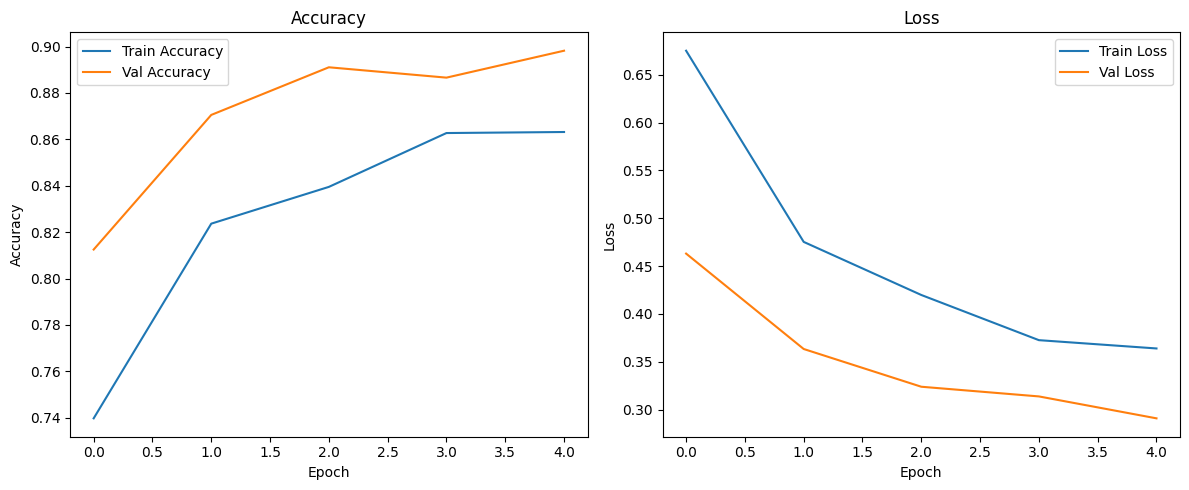

In [13]:
# 9. Plot training history
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

100/100 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.8087 - loss: 0.6827
Test accuracy: 0.8087499737739563
100/100 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.91      0.64      0.75       400
  meningioma       0.79      0.61      0.69       400
     notumor       0.74      0.99      0.85       400
   pituitary       0.84      0.99      0.91       400

    accuracy                           0.81      1600
   macro avg       0.82      0.81      0.80      1600
weighted avg       0.82      0.81      0.80      1600



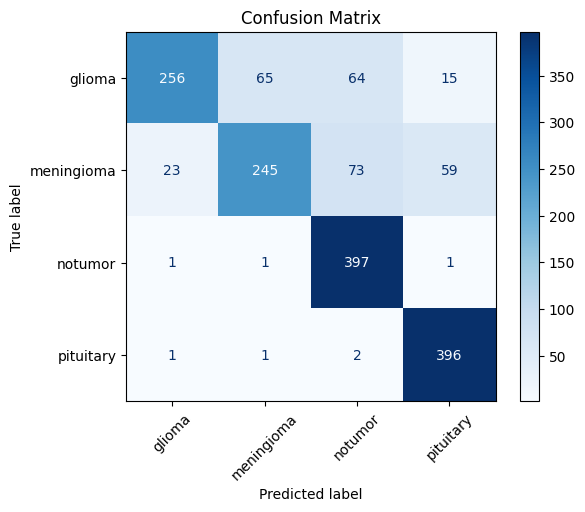

In [14]:
# 10. Evaluate model
test_loss, test_acc = model.evaluate(test_gen)
print("Test accuracy:", test_acc)

# Optional: confusion matrix
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [15]:
# 11. Grad-CAM function
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

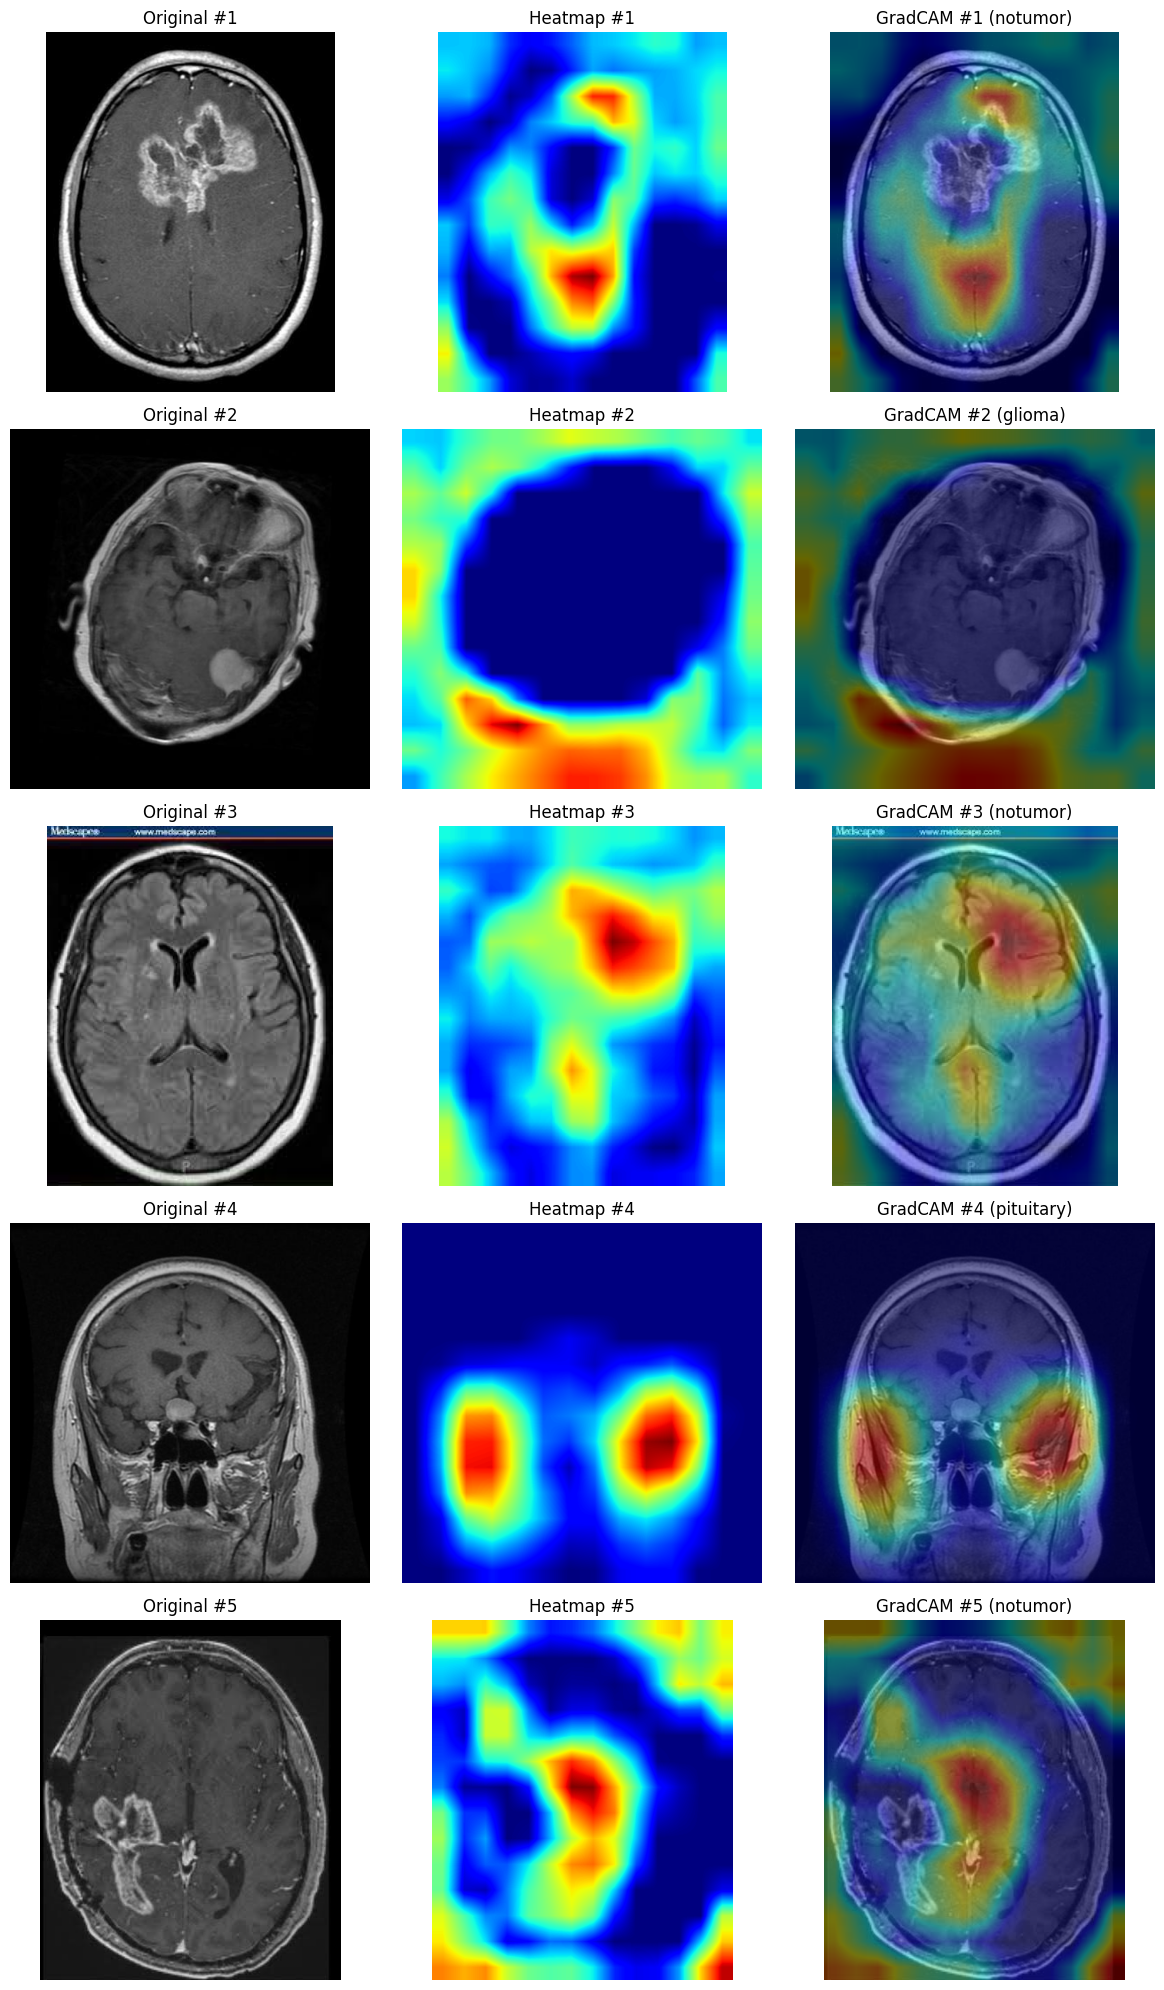

In [16]:
# 12. Show Grad-CAM for 5 sample test images
sample_img_paths = []

for cls in classes:
    cls_dir = os.path.join(test_dir, cls)
    files = os.listdir(cls_dir)

    for f in files[:1]:  # one sample per class if possible
        sample_img_paths.append(os.path.join(cls_dir, f))

# If fewer than 5, fill from any class
all_test_paths = []
for cls in classes:
    cls_dir = os.path.join(test_dir, cls)
    for f in os.listdir(cls_dir):
        all_test_paths.append(os.path.join(cls_dir, f))

while len(sample_img_paths) < 5 and len(all_test_paths) > len(sample_img_paths):
    candidate = all_test_paths[len(sample_img_paths)]
    if candidate not in sample_img_paths:
        sample_img_paths.append(candidate)

sample_img_paths = sample_img_paths[:5]

plt.figure(figsize=(12, 20))

for i, img_path in enumerate(sample_img_paths):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, img_size)
    input_array = np.expand_dims(img_resized / 255.0, axis=0)

    preds = model.predict(input_array, verbose=0)
    pred_class_idx = np.argmax(preds[0])
    pred_class = classes[pred_class_idx]

    heatmap = make_gradcam_heatmap(input_array, model, "block5_conv3")
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized),
        cv2.COLORMAP_JET
    )
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    # Original
    plt.subplot(5, 3, i * 3 + 1)
    plt.title(f"Original #{i+1}")
    plt.imshow(img)
    plt.axis("off")

    # Heatmap
    plt.subplot(5, 3, i * 3 + 2)
    plt.title(f"Heatmap #{i+1}")
    plt.imshow(heatmap_resized, cmap="jet")
    plt.axis("off")

    # GradCAM
    plt.subplot(5, 3, i * 3 + 3)
    plt.title(f"GradCAM #{i+1} ({pred_class})")
    plt.imshow(superimposed_img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# 13. Load ALL test images
img_paths = []
labels = []

for cls in classes:
    cls_dir = os.path.join(test_dir, cls)
    files = os.listdir(cls_dir)

    for f in files:
        img_paths.append(os.path.join(cls_dir, f))
        labels.append(cls)

print("Total test images:", len(img_paths))

Total test images: 1600


In [18]:
# 14. Predict cancer probability for all test images
results = []
cancer_count = 0

if "notumor" not in classes:
    raise ValueError("Class 'notumor' was not found in classes.")

notumor_idx = classes.index("notumor")

for img_path in tqdm(img_paths, desc="Processing test images"):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, img_size)
    input_array = np.expand_dims(img_resized / 255.0, axis=0)

    preds = model.predict(input_array, verbose=0)[0]

    # Cancer probability = 1 - probability of "notumor"
    cancer_prob = 1 - preds[notumor_idx]

    # Count as cancer if >= 50%
    if cancer_prob >= 0.5:
        cancer_count += 1

    # Grad-CAM
    heatmap = make_gradcam_heatmap(input_array, model, "block5_conv3")
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized),
        cv2.COLORMAP_JET
    )
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    gradcam_img = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    results.append((img, gradcam_img, cancer_prob, img_path))

Processing test images: 100%|██████████| 1600/1600 [26:11<00:00,  1.02it/s]


In [19]:
# 15. Calculate cancer patient rate
total = len(img_paths)
cancer_rate = (cancer_count / total) * 100
print(f"{cancer_rate:.2f}% of the total were classified as cancer patients.")

67.62% of the total were classified as cancer patients.


In [20]:
# 16. Sort by highest cancer probability
results.sort(key=lambda x: x[2], reverse=True)
top_results = results[:top_k]

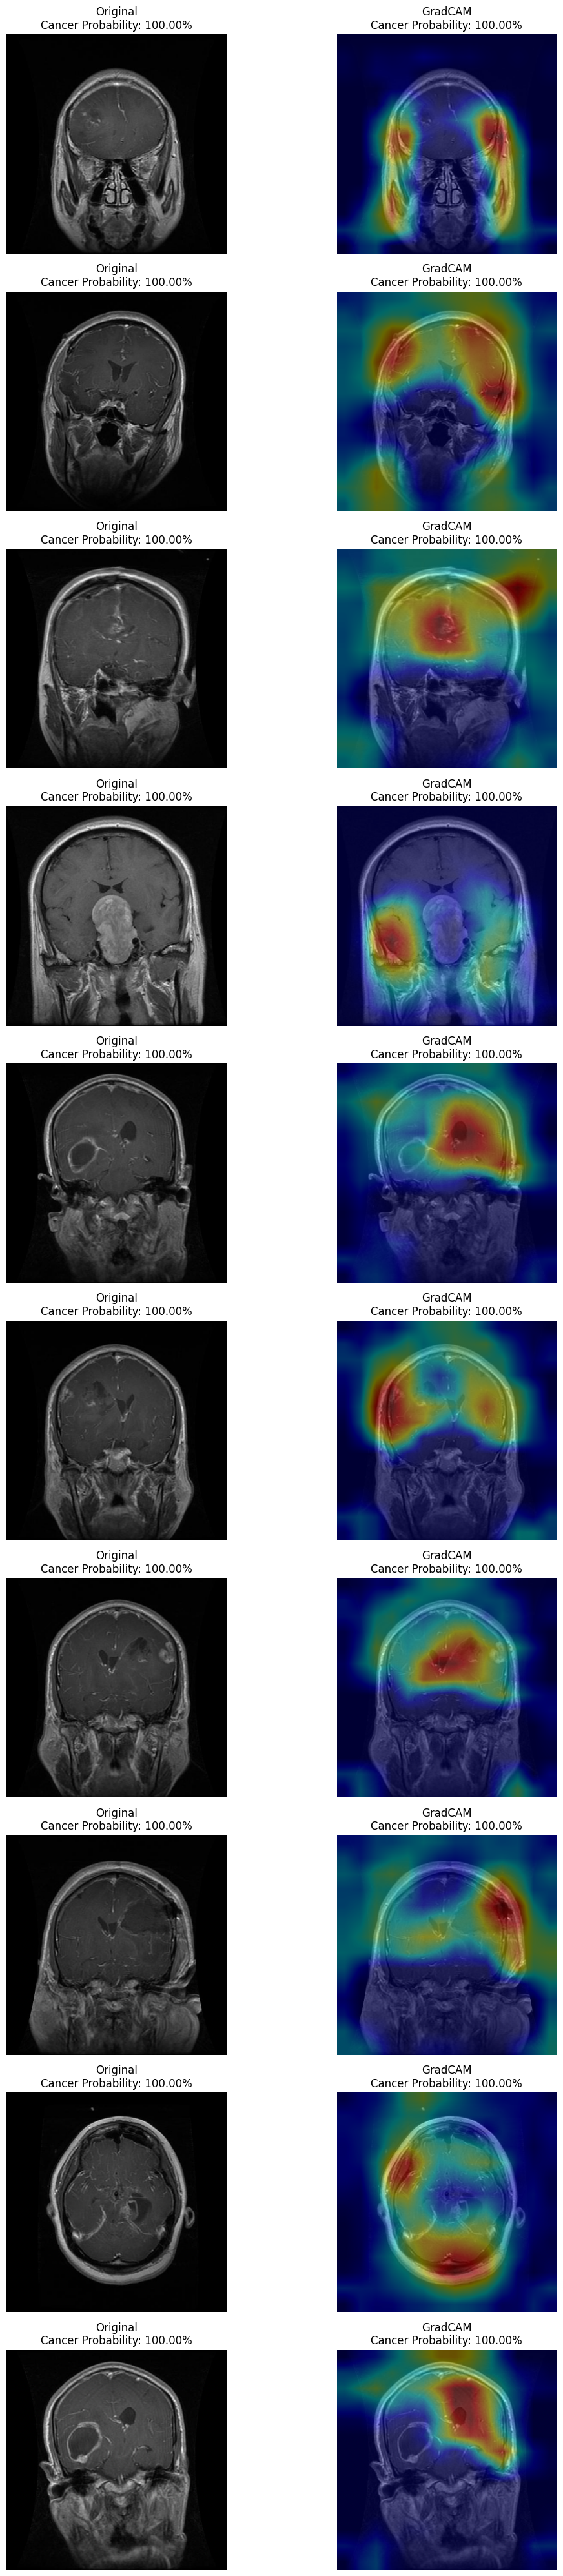

In [21]:
# 17. Show top-k highest cancer probability images
plt.figure(figsize=(12, 4 * top_k))

for i, (orig, grad, prob, path) in enumerate(top_results):
    # Original
    plt.subplot(top_k, 2, i * 2 + 1)
    plt.imshow(orig)
    plt.title(f"Original\nCancer Probability: {prob*100:.2f}%")
    plt.axis("off")

    # Grad-CAM
    plt.subplot(top_k, 2, i * 2 + 2)
    plt.imshow(grad)
    plt.title(f"GradCAM\nCancer Probability: {prob*100:.2f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()